In [3]:
import glob
import sys
import random
import warnings
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import *
import tifffile as tiff
from tfkan import layers
from tfkan.layers import DenseKAN, Conv2DKAN
from tensorflow.nn import silu
from tensorflow.nn import depth_to_space, space_to_depth
from skimage.io import imsave, imread

In [4]:
def get_dataset(X_dir, y_dir):
    
    num_samples = len(X_dir)
    X = []
    y = []
    
    for i in range(num_samples):
        X.append(tiff.imread(X_dir[i]))
        y.append(tiff.imread(y_dir[i]))
    
    y = np.reshape(y, (-1, 512, 512, 1))
    return np.array(X), np.array(y)

In [3]:
import glob
import matplotlib.pyplot as plt
import numpy as np

x_train = glob.glob("G:/Segmentation _Multisensor/Building/Cartosat/Train/Image/*.tif")
y_train = glob.glob("G:/Segmentation _Multisensor/Building/Cartosat/Train/Groundtruth/*.tif")

x_val = glob.glob("G:/Segmentation _Multisensor/Building/Cartosat/Val/Image/*.tif")
y_val = glob.glob("G:/Segmentation _Multisensor/Building/Cartosat/Val/Groundtruth/*.tif")

x_train.sort()
y_train.sort()
x_val.sort()
y_val.sort()

print(len(x_train), len(y_train), len(x_val), len(y_val))

x_train, y_train = get_dataset(x_train, y_train)
x_val, y_val = get_dataset(x_val, y_val)
print(x_train.shape, y_train.shape, x_val.shape, y_val.shape)

1260 1260 356 356
(1260, 512, 512, 3) (1260, 512, 512, 1) (356, 512, 512, 3) (356, 512, 512, 1)


In [5]:
def kan_c(x,f,k):
    c22 = tf.keras.models.Sequential(Conv2DKAN(filters=f, kernel_size=k, strides=1, padding='same', kan_kwargs={'grid_size': 3}))
    c2 = c22(x)
    return c2

In [6]:
def Skip_layer(x1,x2):
    _,h1,w1,f1 = x1.shape
    _,h2,w2,f2 = x2.shape
    
    y1 = AveragePooling2D((h1//16,w1//16),(h1//16,w1//16))(x1)
    y2 = AveragePooling2D((h2//16,w2//16),(h2//16,w2//16))(x2)

    s1 = Reshape([16, 16, f1//4, 4])(y1)
    s1 = Permute([1, 2, 4, 3])(s1)
    s2 = Reshape([16, 16, f2//4, 4])(y2)
    s2 = Permute([1, 2, 4, 3])(s2)
    
    q0 = Concatenate()([s1[:,:,:,0],s2[:,:,:,0]])
    q1 = Concatenate()([s1[:,:,:,1],s2[:,:,:,1]])
    q2 = Concatenate()([s1[:,:,:,2],s2[:,:,:,2]])
    q3 = Concatenate()([s1[:,:,:,3],s2[:,:,:,3]])
   
    c1 = kan_c(q0,f1//4,3)
    c2 = kan_c(q1,f1//4,3)
    c3 = kan_c(q2,f1//4,3)
    c4 = kan_c(q3,f1//4,3)

    c = Concatenate()([c1,c2,c3,c4])

    y = tf.math.reduce_mean(c, axis=3, keepdims=True, name=None)
    y = Activation('sigmoid')(y)

    m1 = Multiply()([c,y])
    eff = kan_c(m1,f2,1)
    
    eff = experimental.preprocessing.Resizing(h2, w2)(eff)
    eff = Add()([eff,x2])
    return eff

In [7]:
def  Dense_multiscale_feature_extraction(x):
    _,h,w,f = x.shape
    y = AveragePooling2D((h//16,w//16),(h//16,w//16))(x)
    get_channel = f//4
    x_ = Reshape([16,16,get_channel,4])(y)
    x_ = Permute([1,2,4,3])(x_)
    x0 = x_[:,:,:,0]
    x1 = x_[:,:,:,1]
    x2 = x_[:,:,:,2]
    x3 = x_[:,:,:,3]
    x0 = DepthwiseConv2D((3,3),1,dilation_rate = (1,1),padding='same')(x0)
    x0 = kan_c(x0,f//4,3)
    x1 = Concatenate()([x0,x1])
    x1 = DepthwiseConv2D((3,3),1,dilation_rate = (2,2),padding='same')(x1)
    x1 = kan_c(x1,f//4,3)
    x2 = Concatenate()([x1,x2])
    x2 = DepthwiseConv2D((3,3),1,dilation_rate = (4,4),padding='same')(x2)
    x2 = kan_c(x2,f//4,3)
    x3 = Concatenate()([x2,x3])
    x3 = DepthwiseConv2D((3,3),1,dilation_rate = (8,8),padding='same')(x3)
    x3 = kan_c(x3,f//4,3)
    y = concatenate([x0,x1,x2,x3], axis=3)
    y = kan_c(y,f,1)
    y = experimental.preprocessing.Resizing(h, w)(y)
    x = Add()([x,y])
    return x

In [8]:
def bnprelu(x):
    bn = BatchNormalization()(x)
    act = Activation('selu')(bn)
    return act
def conv(x,nOut,kSize,strides,padding,dilation=(1,1),groups=1,bn_acti=False,bias=False):
    output = Conv2D(nOut,kSize,strides=strides,padding=padding,dilation_rate=dilation,groups=groups, use_bias=bias)(x)
    if bn_acti:
        output = bnprelu(output)
    return output
def Split(x):
    _,width,height,channel = x.shape
    get_channel = channel//2
    x_ = Reshape([width,height,get_channel,2])(x)
    x_ = Permute([1,2,4,3])(x_)
    x0 = x_[:,:,:,0]
    x1 = x_[:,:,:,1]
    return x0,x1
def Branch1(x,c,d=1,kSize=3,dkSize=3):
    _,h,w,f = x.shape
    br1 = conv(x,c,kSize,1,padding='same',bn_acti=True)
    br2 = conv(br1,c,kSize,1,padding='same',bn_acti=True)
    br3 = conv(br1,c,kSize,1,padding='same',bn_acti=True)
    br = br1+br1+br2
    output = Activation('sigmoid')(br)
    output = Multiply()([x,output])
    return output,br
def Branch2(x,c,d=1,kSize=3,dkSize=3):
    _,h,w,f = x.shape
    br1 = conv(x,c,kSize,1,padding='same',bn_acti=True)
    br = AveragePooling2D((h//16,w//16),(h//16,w//16))(br1)
    br2 = kan_c(br,c,1)
    br3 = kan_c(br,c,3)
    br2 = experimental.preprocessing.Resizing(h, w)(br2)
    br3 = experimental.preprocessing.Resizing(h, w)(br3)
    br = br1+br2+br3
    output = Activation('sigmoid')(br)
    output = Multiply()([x,output])
    return output,br
def  Split_wise_feature_extraction(x,d=1,dropout=0,p=0.5):
    _,h,w,nIn = x.shape
    c = nIn-int(nIn*(1-p))
    output1, output2 = Split(x)
    output1,out1 = Branch1(output1,c,d)
    output2,out2 = Branch2(output2,c,d)
    output = Concatenate()([output1, output2])
    out = Concatenate()([out1, out2])
    output = conv(output,nIn, 1, 1, padding='valid', bn_acti=True)
    out = conv(out,nIn, 1, 1, padding='valid', bn_acti=True)
    output = Add()([output,out])
    return output

In [10]:
def jaccard(y_true, y_pred, smooth=1e-7):
    intersection = tf.reduce_sum(y_true * y_pred, axis=(1, 2))
    union = tf.reduce_sum(y_true, axis=(1, 2)) +tf.reduce_sum(y_pred,axis=(1, 2)) - intersection
    jaccard = (intersection + smooth) / (union + smooth)
    return jaccard
def boundary_JI(true, pred, theta0=3, theta=5):
    n, h, w, c = pred.shape
    kernel_theta0 = [theta0, theta0]
    kernel_theta = [theta, theta]
    one_hot_gt = true
    one_hot_gt_neg = 1.0 - one_hot_gt
    gt_b = tf.nn.max_pool2d(tf.transpose(one_hot_gt_neg, perm=[0, 3, 1, 2]), ksize=kernel_theta0,strides=1,padding='SAME')
    gt_b = tf.transpose(gt_b, perm=[0, 2, 3, 1]) 
    gt_b -= one_hot_gt_neg
    
    pred_neg = 1.0 - pred
    pred_b = tf.nn.max_pool2d(tf.transpose(pred_neg, perm=[0, 3, 1, 2]), ksize=kernel_theta0,strides=1,padding='SAME')
    pred_b = tf.transpose(pred_b, perm=[0, 2, 3, 1])
    pred_b -= pred_neg
    gt_b_ext = tf.nn.max_pool2d(tf.transpose(gt_b, perm=[0, 3, 1, 2]),ksize=kernel_theta,strides=1,padding='SAME')
    gt_b_ext = tf.transpose(gt_b_ext, perm=[0, 2, 3, 1])
    pred_b_ext = tf.nn.max_pool2d(tf.transpose(pred_b, perm=[0, 3, 1, 2]), ksize=kernel_theta,strides=1,padding='SAME')
    pred_b_ext = tf.transpose(pred_b_ext, perm=[0, 2, 3, 1])
    
    ji = jaccard(gt_b_ext, pred_b_ext)
    return ji

In [11]:
def KANBDNet(input_size=(512,512,3)):
    inputs = Input(input_size)

    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same') (inputs)
    c1 = Split_wise_feature_extraction(c1,dropout=0,p=0.5)
    c1 = Split_wise_feature_extraction(c1,dropout=0,p=0.5)
    p1 = MaxPooling2D((2, 2)) (c1)

    c2 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same') (p1)
    c2 = Split_wise_feature_extraction(c2,dropout=0,p=0.5)
    c2 = Split_wise_feature_extraction(c2,dropout=0,p=0.5)
    p2 = MaxPooling2D((2, 2)) (c2)

    c3 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same') (p2)
    c3 = Split_wise_feature_extraction(c3,dropout=0,p=0.5)
    c3 = Split_wise_feature_extraction(c3,dropout=0,p=0.5)
    p3 = MaxPooling2D((2, 2)) (c3)

    c4 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same') (p3)
    c4 = Dropout(0.2) (c4)
    c4 = Split_wise_feature_extraction(c4,dropout=0,p=0.5)
    c4 = Split_wise_feature_extraction(c4,dropout=0,p=0.5)
    p4 = MaxPooling2D(pool_size=(2, 2)) (c4)

    c5 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same') (p4)
    c5 = Dropout(0.4) (c5)
    c5 = Dense_multiscale_feature_extraction(c5)

    u6 = Conv2DTranspose(32, (2, 2), activation='relu', strides=(2, 2), padding='same') (c5)
    m1 = Skip_layer(c5,c4)
    u6 = concatenate([u6, m1])
    c6 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same') (u6)
    c6 = Dropout(0.2) (c6)

    u7 = Conv2DTranspose(32, (2, 2), activation='relu', strides=(2, 2), padding='same') (c6)
    m2 = Skip_layer(c5,c3)
    u7 = concatenate([u7, m2])
    c7 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same') (u7)

    u8 = Conv2DTranspose(16, (2, 2), activation='relu', strides=(2, 2), padding='same') (c7)
    m3 = Skip_layer(c5,c2)
    u8 = concatenate([u8, m3])
    c8 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same') (u8)

    u9 = Conv2DTranspose(16, (2, 2), activation='relu', strides=(2, 2), padding='same') (c8)
    m4 = Skip_layer(c5,c1)
    u9 = concatenate([u9, m4], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same') (u9)
    
    outputs = Conv2D(1, (1, 1), activation='sigmoid') (c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

In [12]:
model = KANBDNet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[boundary_JI,'accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 512, 512, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 512, 512, 16) 448         input_1[0][0]                    
__________________________________________________________________________________________________
reshape (Reshape)               (None, 512, 512, 8,  0           conv2d[0][0]                     
__________________________________________________________________________________________________
permute (Permute)               (None, 512, 512, 2,  0           reshape[0][0]                    
______________________________________________________________________________________________

In [13]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(model, batch_size=None):
    if batch_size is None:
        batch_size = 1

    real_model =tf.function(model).get_concrete_function(tf.TensorSpec([batch_size] +model.inputs[0].shape[1:], model.inputs[0].dtype))
    frozen_func, graph_def =convert_variables_to_constants_v2_as_graph(real_model)

    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(graph=frozen_func.graph,
                                            run_meta=run_meta,cmd='op', options=opts)
    return flops.total_float_ops

flops = get_flops(model,2)
flops

Instructions for updating:
Use `tf.compat.v1.graph_util.tensor_shape_from_node_def_name`


17344845104

In [12]:
import math
import time
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_boundary_JI',mode='max',factor=0.5,patience=10,verbose=1,cooldown=1,min_delta=0.0001)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_boundary_JI', min_delta=0.0001, patience=20, verbose=1,mode = 'max', restore_best_weights = True)
check_path = 'G:/Segmentation _Multisensor/Weights/Binary_Building/Proposed/normal13.h5'
checkpoint = tf.keras.callbacks.ModelCheckpoint(check_path,monitor='val_boundary_JI',verbose=1,save_best_only=True,save_weights_only=True,mode='max')
t1 = time.time()
history=model.fit(x=x_train,y=y_train,validation_data=(x_val,y_val),batch_size=2,shuffle=True,verbose=1,epochs=300,
                  callbacks=[reduce_lr,early_stop,checkpoint])
t2 = time.time()
print(t2-t1)

Epoch 1/300
630/630 [==============================] - 229s 313ms/step - loss: 0.3519 - boundary_JI: 0.0707 - accuracy: 0.8407 - val_loss: 0.3451 - val_boundary_JI: 0.0707 - val_accuracy: 0.8549

Epoch 00001: val_boundary_JI improved from -inf to 0.07073, saving model to G:/Segmentation _Multisensor/Weights/Binary_Building/Proposed\normal13.h5
Epoch 2/300
630/630 [==============================] - 210s 334ms/step - loss: 0.2949 - boundary_JI: 0.0723 - accuracy: 0.8695 - val_loss: 0.3487 - val_boundary_JI: 0.0694 - val_accuracy: 0.8519

Epoch 00002: val_boundary_JI did not improve from 0.07073
Epoch 3/300
630/630 [==============================] - 209s 331ms/step - loss: 0.2707 - boundary_JI: 0.0759 - accuracy: 0.8819 - val_loss: 0.2950 - val_boundary_JI: 0.0722 - val_accuracy: 0.8696

Epoch 00003: val_boundary_JI improved from 0.07073 to 0.07221, saving model to G:/Segmentation _Multisensor/Weights/Binary_Building/Proposed\normal13.h5
Epoch 4/300
630/630 [==============================

In [12]:
model.load_weights('G:/Segmentation _Multisensor/Weights/Binary_Building/Proposed/Proposed/cart13.h5')
import os
gtappend = []
predappend = []

addA = "G:/Segmentation _Multisensor/Building/Cartosat/Test/Image/"
addlabel = "G:/Segmentation _Multisensor/Building/Cartosat/Test/Groundtruth/"

for eg in os.listdir(addA):
    imageA = addA + str(eg)
    GT = addlabel + str(eg)
    x1 = tiff.imread(imageA) 
    x2 = tiff.imread(GT)
    a = np.reshape(x1[:,:,0:3],(1,512,512,3))
    y = model.predict(a)
    y = np.reshape(y,(512,512))
    result = np.where(y>0.5,1,0)
    predappend.append(result)
    gtappend.append(x2)

g = np.stack(gtappend, axis=0)
p = np.stack(predappend, axis=0)

from sklearn.metrics import *
gt=(g.ravel()).astype('int')
pd=(p.ravel()).astype('int')
f1 = f1_score(gt,pd,average='macro')
kappa = cohen_kappa_score(gt,pd)
accuracy = accuracy_score(gt,pd)
jaccard = jaccard_score(gt,pd,average='macro')
precision = precision_score(gt,pd,average='macro')
recall = recall_score(gt,pd,average='macro')
print(np.unique(gt),np.unique(pd))
print("F1 SCORE:", f1)
print("Kappa:",kappa)
print("Accuracy:",accuracy)
print("Jaccard Score:",jaccard)
print("Precision:",precision)
print("Recall:",recall)

def get_dice(y_true, y_pred):
    intersection = np.sum(y_true * y_pred, axis=(0, 1, 2))
    union = np.sum(y_true**2, axis=(0, 1, 2)) + np.sum(y_pred**2, axis=(0, 1, 2))
    dc = 2 * intersection / union
    return dc
 
dice_coeff = get_dice(g, p)
print("dc = ",np.mean(dice_coeff))

[0 1] [0 1]
F1 SCORE: 0.8781324183246639
Kappa: 0.7562845194047618
Accuracy: 0.9182714612296458
Jaccard Score: 0.7896974660832541
Precision: 0.8830283058930047
Recall: 0.873498427043711
dc =  0.8081921002699634


In [11]:
model.load_weights('G:/Segmentation _Multisensor/Weights/Binary_Building/Proposed/Proposed/Proposed_cart13.h5')

0.42295002937316895


C:\Users\user\AppData\Local\Temp\ipykernel_329744\1887676518.py:26: UserWarning: G:/Segmentation _Multisensor/Building/Proposed/Results/pr/Ban/prop_ban2.png is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  imsave("G:/Segmentation _Multisensor/Building/Proposed/Results/pr/Ban/prop_ban2.png", np.reshape(y_pred,(512,512)))


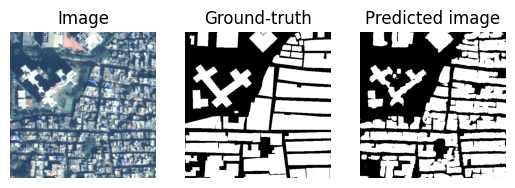

In [13]:
import time
img = tiff.imread("G:/Segmentation _Multisensor/Building/Cartosat/Test/Image/610_Ban.tif")
y_test = tiff.imread("G:/Segmentation _Multisensor/Building/Cartosat/Test/Groundtruth/610_Ban.tif")
x_test = np.expand_dims(img,axis=0)
t0 = time.time()
y_pred = model.predict(x_test)
t1 = time.time()
print(t1-t0)
fig = plt.figure()
fig.figsize = (30,30)
y_pred = y_pred>0.5
ax = fig.add_subplot(1,3,1)
ax.imshow(np.reshape(x_test,(512,512,3)))
plt.axis('off')
plt.title("Image")

ax = fig.add_subplot(1,3,2)
ax.imshow(np.reshape(y_test,(512,512)),cmap="gray")
plt.axis('off')
plt.title("Ground-truth")

ax = fig.add_subplot(1,3,3)
ax.imshow(np.reshape(y_pred,(512,512)),cmap="gray")
plt.axis('off')
plt.title("Predicted image")
imsave("G:/Segmentation _Multisensor/Building/Proposed/Results/pr/Ban/prop_ban2.png", np.reshape(y_pred,(512,512)))

0.13833165168762207


Text(0.5, 1.0, 'Predicted image')

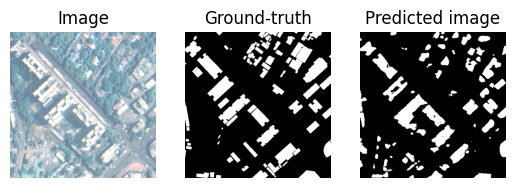

In [25]:
import time
img = tiff.imread("G:/Segmentation _Multisensor/Building/Cartosat/Test/Image/1390_Bh.tif")
y_test = tiff.imread("G:/Segmentation _Multisensor/Building/Cartosat/Test/Groundtruth/1390_Bh.tif")
x_test = np.expand_dims(img,axis=0)
t0 = time.time()
y_pred = model.predict(x_test)
t1 = time.time()
print(t1-t0)
fig = plt.figure()
fig.figsize = (30,30)
y_pred = y_pred>0.5
ax = fig.add_subplot(1,3,1)
ax.imshow(np.reshape(x_test,(512,512,3)))
plt.axis('off')
plt.title("Image")

ax = fig.add_subplot(1,3,2)
ax.imshow(np.reshape(y_test,(512,512)),cmap="gray")
plt.axis('off')
plt.title("Ground-truth")

ax = fig.add_subplot(1,3,3)
ax.imshow(np.reshape(y_pred,(512,512)),cmap="gray")
plt.axis('off')
plt.title("Predicted image")
# imsave("G:/Segmentation _Multisensor/Building/Proposed/Results/pr/Bh/prop_bh3.png", np.reshape(y_pred,(512,512)))

0.46712493896484375


C:\Users\user\AppData\Local\Temp\ipykernel_329744\278999128.py:26: UserWarning: G:/Segmentation _Multisensor/Building/Proposed/Results/pr/Im/prop_im3.png is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  imsave("G:/Segmentation _Multisensor/Building/Proposed/Results/pr/Im/prop_im3.png", np.reshape(y_pred,(512,512)))


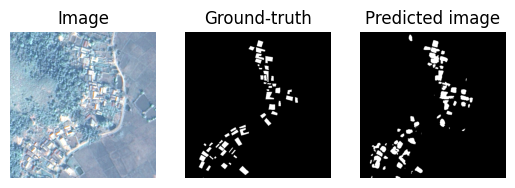

In [22]:
import time
img = tiff.imread("G:/Segmentation _Multisensor/Building/Cartosat/Test/Image/655_Imp.tif")
y_test = tiff.imread("G:/Segmentation _Multisensor/Building/Cartosat/Test/Groundtruth/655_Imp.tif")
x_test = np.expand_dims(img,axis=0)
t0 = time.time()
y_pred = model.predict(x_test)
t1 = time.time()
print(t1-t0)
fig = plt.figure()
fig.figsize = (30,30)
y_pred = y_pred>0.5
ax = fig.add_subplot(1,3,1)
ax.imshow(np.reshape(x_test,(512,512,3)))
plt.axis('off')
plt.title("Image")

ax = fig.add_subplot(1,3,2)
ax.imshow(np.reshape(y_test,(512,512)),cmap="gray")
plt.axis('off')
plt.title("Ground-truth")

ax = fig.add_subplot(1,3,3)
ax.imshow(np.reshape(y_pred,(512,512)),cmap="gray")
plt.axis('off')
plt.title("Predicted image")
imsave("G:/Segmentation _Multisensor/Building/Proposed/Results/pr/Im/prop_im3.png", np.reshape(y_pred,(512,512)))